## 1. Descriptive Statistics Analysis - Wine Quality Dataset

1. Tổng quan về cấu trúc bộ dữ liệu (Multivariate).
2. Tính toán các đại lượng thống kê: Mean, Variance cho Quần thể và Mẫu.
3. Phân tích hệ số tương quan giữa các biến.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))  
from source.utils import mean, variance, standard_deviation, covariance, correlation

sns.set_style("whitegrid")

try:
    df = pd.read_csv("../data/WineQT.csv")
    features = df.drop(columns=["quality", "Id"])
    print("Tải dữ liệu thành công.")
except FileNotFoundError:
    print("Không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn.")

print(df.head())

Tải dữ liệu thành công.
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8

## Tổng quan dữ liệu

In [3]:
print("Cấu trúc dữ liệu nhiều biến:")
print(f"Số lượng sample: {features.shape[0]}")
print(f"Số lượng cột (biến): {features.shape[1]}")
print("-" * 30)
features.info()

Cấu trúc dữ liệu nhiều biến:
Số lượng sample: 1143
Số lượng cột (biến): 11
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
dtypes: float64(11)
memory usage: 98.4 KB


## Mean và Variance

In [5]:
N = len(features)
n_sample = 100
df_sample = features.sample(n=n_sample, random_state=42)

# Population
pop_mean = {col: mean(features[col]) for col in features.columns}
pop_var = {col: variance(features[col]) for col in features.columns}
pop_std = {col: standard_deviation(features[col]) for col in features.columns}

# 3. Mean and Variance of the Sample
sample_mean = {col: mean(df_sample[col]) for col in df_sample.columns}
sample_var = {col: variance(df_sample[col]) for col in df_sample.columns}
sample_std = {col: standard_deviation(df_sample[col]) for col in df_sample.columns}

# Tạo bảng so sánh cho một biến cụ thể
rows = []
for col in features.columns:
    rows.append({
        "Variable": col,
        "Population Mean": pop_mean[col],
        "Sample Mean": sample_mean[col],
        "Population Variance": pop_var[col],
        "Sample Variance": sample_var[col],
        "Population Std Dev": pop_std[col],
        "Sample Std Dev": sample_std[col]
    })

comparison = pd.DataFrame(rows).set_index("Variable")
print(comparison.to_string())

                      Population Mean  Sample Mean  Population Variance  Sample Variance  Population Std Dev  Sample Std Dev
Variable                                                                                                                    
fixed acidity                8.311111     8.393000             3.054088         3.400254            1.747595        1.843978
volatile acidity             0.531339     0.536400             0.032268         0.034986            0.179633        0.187045
citric acid                  0.268364     0.269900             0.038685         0.040849            0.196686        0.202113
residual sugar               2.532152     2.477500             1.838512         1.258049            1.355917        1.121628
chlorides                    0.086933     0.088390             0.002234         0.002561            0.047267        0.050604
free sulfur dioxide         15.615486    14.190000           105.072466        76.963535           10.250486        8.772886


## Phân tích tương quan

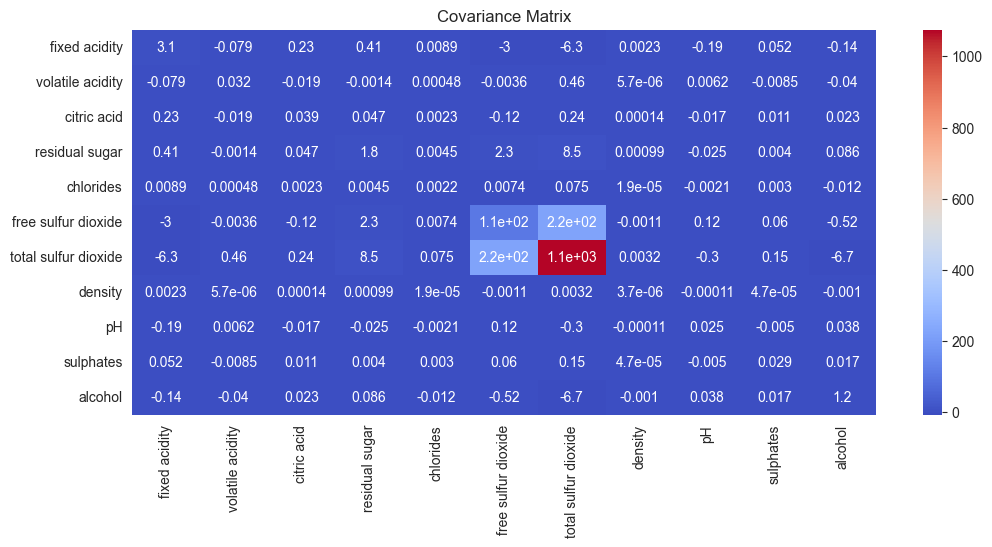

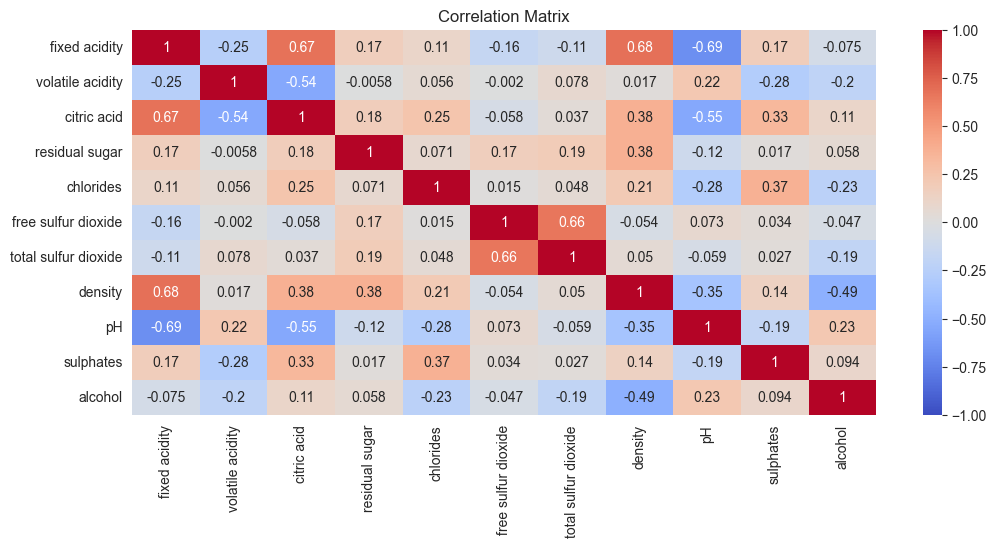

In [6]:
# Correlation Matrix & Correlation Matrix
var_list = features.columns.tolist()
p = len(var_list)

cov_matrix = np.zeros((p, p))
corr_matrix = np.zeros((p, p))
for i, vi in enumerate(var_list):
    for j, vj in enumerate(var_list):
        cov_matrix[i, j] = covariance(features[vi], features[vj], is_population=False)
        corr_matrix[i, j] = correlation(features[vi], features[vj])

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
sns.heatmap(cov_matrix, annot=True, xticklabels=var_list, yticklabels=var_list, cmap="coolwarm")
plt.title("Covariance Matrix")
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
sns.heatmap(corr_matrix, annot=True, xticklabels=var_list, yticklabels=var_list, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

## Visualization


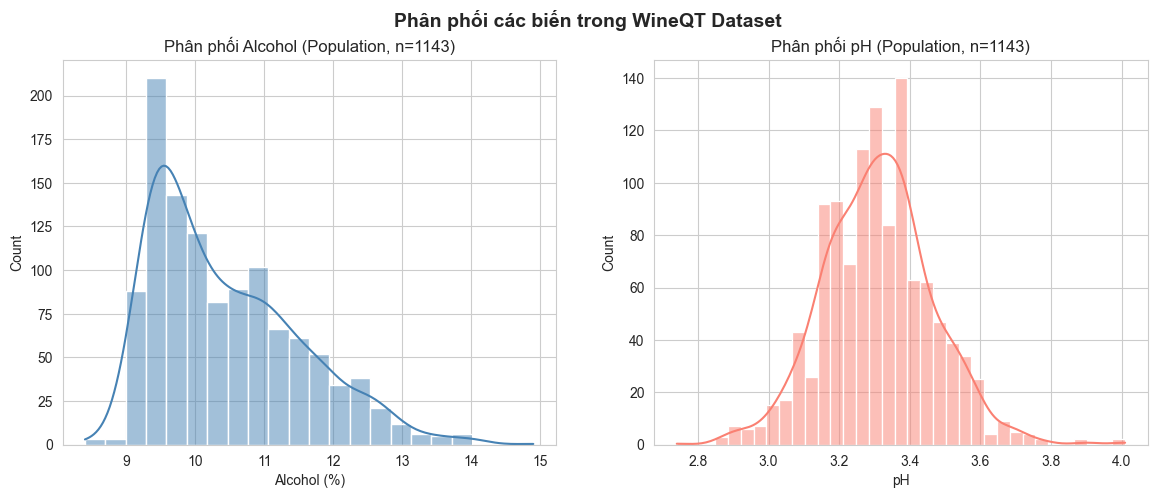

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(features["alcohol"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Phân phối Alcohol (Population, n=1143)", fontsize=12)
axes[0].set_xlabel("Alcohol (%)")

sns.histplot(features["pH"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Phân phối pH (Population, n=1143)", fontsize=12)
axes[1].set_xlabel("pH")

plt.suptitle("Phân phối các biến trong WineQT Dataset", fontsize=14, fontweight="bold")
plt.show()

In [8]:
# Minh hoạ ý nghĩa hình học với 2 biến: alcohol & volatile acidity
v1_name, v2_name = "alcohol", "volatile acidity"
v1 = features[v1_name].values
v2 = features[v2_name].values
x1_bar, x2_bar = pop_mean[v1_name], pop_mean[v2_name]

d1 = v1 - x1_bar   
d2 = v2 - x2_bar  
L1 = np.sqrt(np.dot(d1, d1))
L2 = np.sqrt(np.dot(d2, d2))
cos_theta = np.dot(d1, d2) / (L1 * L2)
theta_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

print(f"Biến 1: {v1_name}")
print(f"Mean = {x1_bar:.4f}")
print(f"Var  = {pop_var[v1_name]:.4f}")
print(f"Std  = {pop_std[v1_name]:.4f}")
print(f"||d1|| (Population Std × √n) = {L1:.4f}")
print()
print(f"Biến 2: {v2_name}")
print(f"Mean = {x2_bar:.4f}")
print(f"Var = {pop_var  [v2_name]:.4f}")
print(f"Std = {pop_std[v2_name]:.4f}")
print(f"||d2|| = {L2:.4f}")
print()
print(f"Góc θ giữa d1 và d2 = {theta_deg:.2f}°")
print(f"cos(θ) = r(alcohol, volatile acidity) = {cos_theta:.4f}")
print()
print(f"Xác nhận: correlation() = {correlation(features[v1_name], features[v2_name]):.4f}")

Biến 1: alcohol
Mean = 10.4421
Var  = 1.1711
Std  = 1.0822
||d1|| (Population Std × √n) = 36.5712

Biến 2: volatile acidity
Mean = 0.5313
Var = 0.0323
Std = 0.1796
||d2|| = 6.0704

Góc θ giữa d1 và d2 = 101.77°
cos(θ) = r(alcohol, volatile acidity) = -0.2039

Xác nhận: correlation() = -0.2039


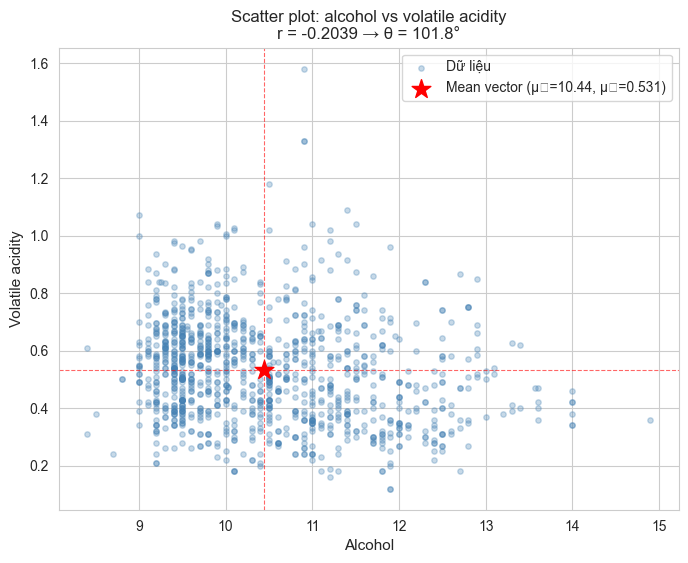

In [10]:
# Biểu đồ scatter + mean point để minh hoạ Mean Vector
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(features[v1_name], features[v2_name], alpha=0.3, s=15, color="steelblue", label="Dữ liệu")
ax.scatter([x1_bar], [x2_bar], s=200, color="red", zorder=5, marker="*",
           label=f"Mean vector (μ₁={x1_bar:.2f}, μ₂={x2_bar:.3f})")
ax.axvline(x1_bar, color="red", lw=0.8, ls="--", alpha=0.6)
ax.axhline(x2_bar, color="red", lw=0.8, ls="--", alpha=0.6)
ax.set_xlabel(v1_name.capitalize(), fontsize=11)
ax.set_ylabel(v2_name.capitalize(), fontsize=11)
ax.set_title(f"Scatter plot: {v1_name} vs {v2_name}\n"
             f"r = {cos_theta:.4f} → θ = {theta_deg:.1f}°", fontsize=12)
ax.legend(fontsize=10)
plt.show()